In [19]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.cm as cm 
import matplotlib.colors as mcolors
from matplotlib.ticker import AutoMinorLocator

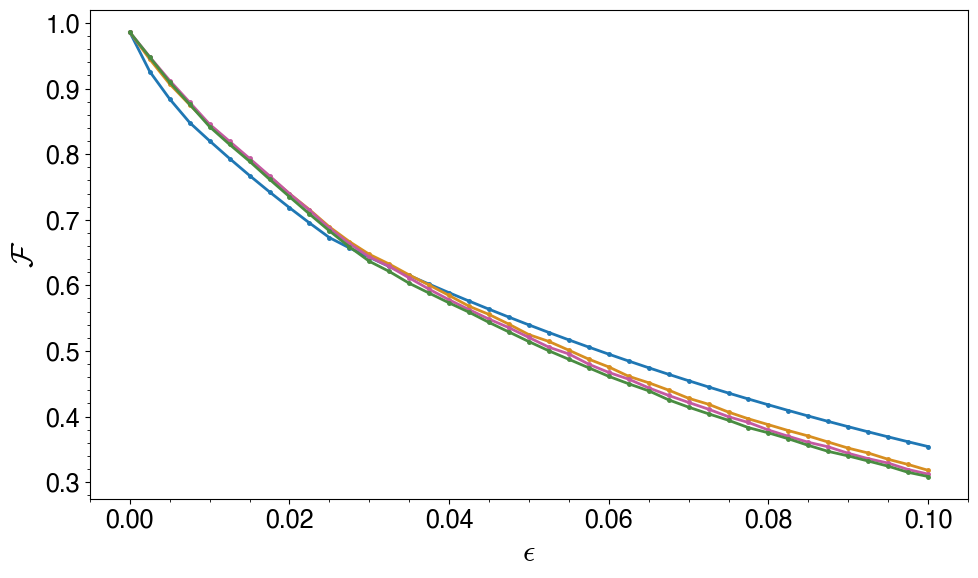

In [20]:
# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 18          # Tick labels
mpl.rcParams['ytick.labelsize'] = 18
# ==========================================================================
plt.figure(figsize=(10, 6))


custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']
# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, color= color, label=f'nqpa={nqpa}', marker='.', markersize=5, linewidth=2)

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.tick_params(which="both", direction="in", top=True, right=True)
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
plt.tight_layout()
# plt.legend()
plt.savefig('aer_trotter_estimation/big.pdf', bbox_inches='tight')

plt.show()
plt.close()

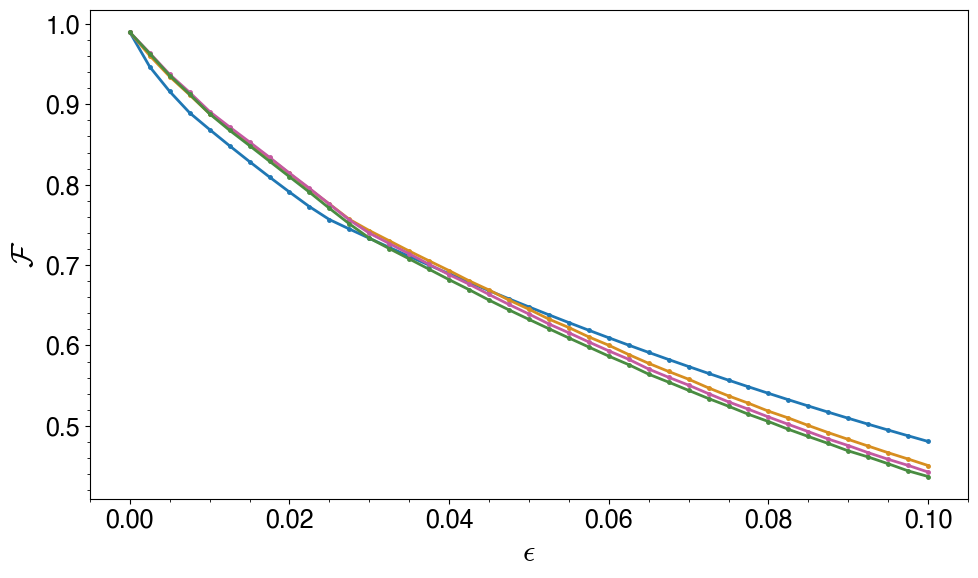

In [147]:
# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 18          # Tick labels
mpl.rcParams['ytick.labelsize'] = 18
# ==========================================================================
plt.figure(figsize=(10, 6))


custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']
# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, color= color, label=f'nqpa={nqpa}', marker='.', markersize=5, linewidth=2)

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.tick_params(which="both", direction="in", top=True, right=True)
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
plt.tight_layout()
# plt.legend()
plt.savefig('aer_trotter_estimation/big_k=3.pdf', bbox_inches='tight')

plt.show()
plt.close()

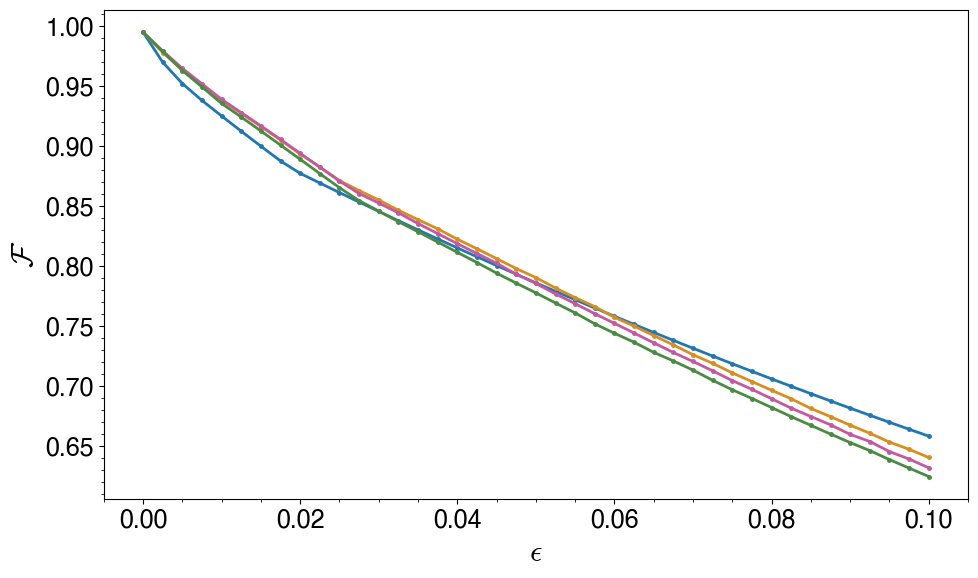

In [148]:
# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 18          # Tick labels
mpl.rcParams['ytick.labelsize'] = 18
# ==========================================================================
plt.figure(figsize=(10, 6))


custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']
# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k2_shots1024000_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())

for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, color= color, label=f'nqpa={nqpa}', marker='.', markersize=5, linewidth=2)

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.tick_params(which="both", direction="in", top=True, right=True)
plt.xlabel('$\epsilon$')
plt.ylabel('$\mathcal{F}$')
plt.tight_layout()
# plt.legend()
plt.savefig('aer_trotter_estimation/big_k=2.pdf', bbox_inches='tight')

plt.show()
plt.close()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_16879/1794596146.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))


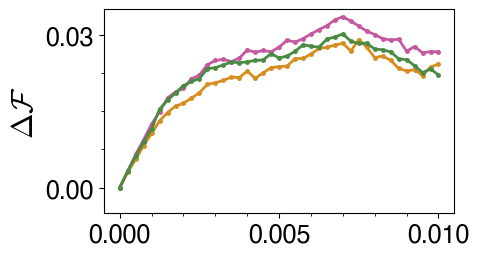

In [21]:
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import cm

plt.figure(figsize=(5, 2.8))

# Load and group files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign color
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))

# Store base for nqpa=0
base_fid_dict = {}

# Extract fidelity curves
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]
    fidelity_curves[nqpa] = (eps_sorted, fids_sorted)

    if nqpa == 0:
        base_fid_dict = dict(zip(eps_sorted, fids_sorted))

# Plot difference from nqpa=0
for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    if nqpa == 0:
        continue  # Skip baseline

    eps, fids = fidelity_curves[nqpa]
    base_fids = [base_fid_dict.get(e, 0) for e in eps]
    delta_fids = [f - b for f, b in zip(fids, base_fids)]

    plt.plot(eps, delta_fids, color=color, label=f'nqpa={nqpa}',  marker='.', markersize=5, linewidth=2)

# Axes tweaks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks([0.0, 0.005, 0.01])
plt.yticks([-0.03, 0.00, 0.03])
plt.ylabel(r"$\mathcal{\Delta F}$")
plt.ylim(-0.005, 0.035)
# plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('aer_trotter_estimation/inset.pdf', bbox_inches='tight')
# plt.legend()
plt.show()


/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_30964/870529040.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))


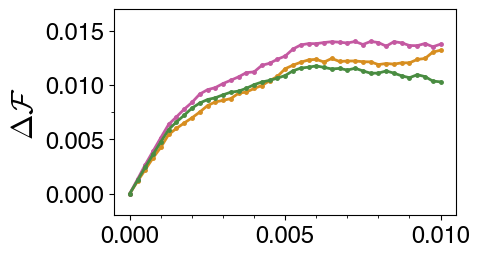

In [142]:
plt.figure(figsize=(5, 2.8))

# Load and group files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k2_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign color
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))

# Store base for nqpa=0
base_fid_dict = {}

# Extract fidelity curves
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]
    fidelity_curves[nqpa] = (eps_sorted, fids_sorted)

    if nqpa == 0:
        base_fid_dict = dict(zip(eps_sorted, fids_sorted))

# Plot difference from nqpa=0
for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    if nqpa == 0:
        continue  # Skip baseline

    eps, fids = fidelity_curves[nqpa]
    base_fids = [base_fid_dict.get(e, 0) for e in eps]
    delta_fids = [f - b for f, b in zip(fids, base_fids)]

    plt.plot(eps, delta_fids, color=color, label=f'nqpa={nqpa}',  marker='.', markersize=5, linewidth=2)

# Axes tweaks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks([0.0, 0.005, 0.01])
plt.yticks([-0.03, 0, 0.005, 0.010, 0.015])
plt.ylabel(r"$\mathcal{\Delta F}$")
plt.ylim(-0.002, 0.017)
# plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('aer_trotter_estimation/insetk=2.pdf', bbox_inches='tight')
# plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_30964/4088557249.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))


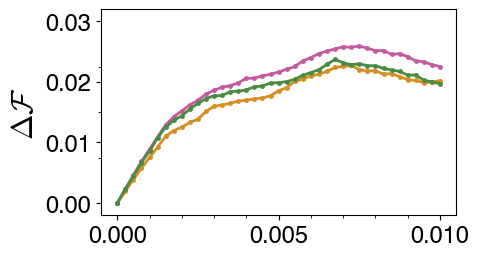

In [140]:
plt.figure(figsize=(5, 2.8))

# Load and group files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k3_shots1024000_eps0.0-0.01_s41_t1.0_J1.0_h1.0/*_combined.csv"))

grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign color
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))

# Store base for nqpa=0
base_fid_dict = {}

# Extract fidelity curves
fidelity_curves = {}
for nqpa in nqpas:
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]
    fidelity_curves[nqpa] = (eps_sorted, fids_sorted)

    if nqpa == 0:
        base_fid_dict = dict(zip(eps_sorted, fids_sorted))

# Plot difference from nqpa=0
for idx, nqpa in enumerate(nqpas):
    color = custom_colors[idx % len(custom_colors)]
    if nqpa == 0:
        continue  # Skip baseline

    eps, fids = fidelity_curves[nqpa]
    base_fids = [base_fid_dict.get(e, 0) for e in eps]
    delta_fids = [f - b for f, b in zip(fids, base_fids)]

    plt.plot(eps, delta_fids, color=color, label=f'nqpa={nqpa}',  marker='.', markersize=5, linewidth=2)

# Axes tweaks
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xticks([0.0, 0.005, 0.01])
plt.yticks([-0.03, 0.00, 0.01,0.02, 0.03])
plt.ylabel(r"$\mathcal{\Delta F}$")
plt.ylim(-0.002, 0.032)
# plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('aer_trotter_estimation/insetk=3.pdf', bbox_inches='tight')
# plt.legend()
plt.show()

/var/folders/hv/vrlxqgrs1bl41tsgjk0ptb280000gn/T/ipykernel_30964/1669861597.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors


<Figure size 1000x600 with 0 Axes>

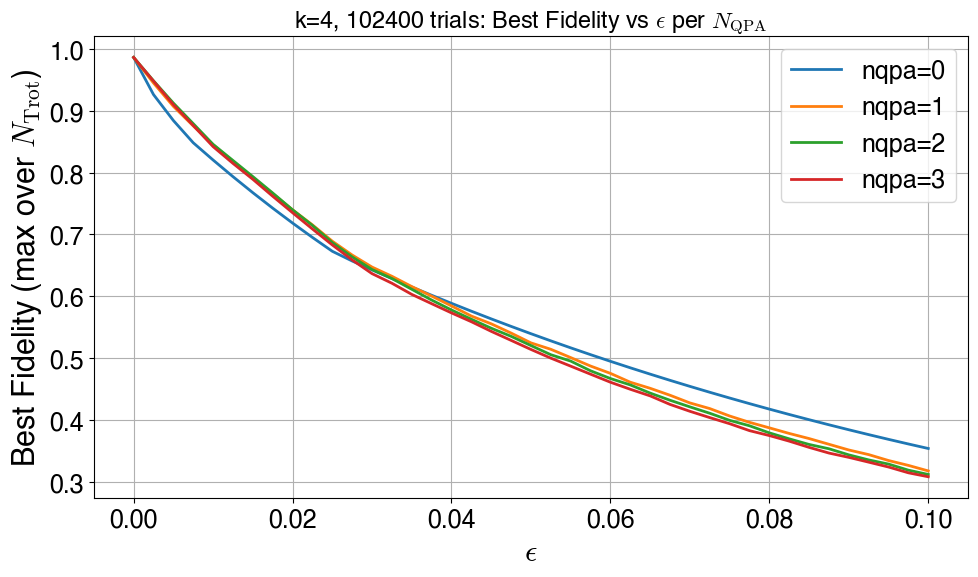

In [11]:
plt.figure(figsize=(10, 6))

# Look for all combined output files
files = sorted(glob.glob("aer_trotter_estimation/estimation_k4_shots102400_eps0.0-0.1_s41_t1.0_J1.0_h1.0/*_combined.csv"))

# Collect data grouped by nqpa
grouped = {}
for file in files:
    match = re.search(r'nqpa(\d+)_ntrot(\d+)', file)
    if match:
        nqpa = int(match.group(1))
        ntrot = int(match.group(2))
        grouped.setdefault(nqpa, []).append((ntrot, file))
    else:
        print(f"Skipping {file} — filename pattern not matched")

# Assign a color per nqpa
nqpas = sorted(grouped.keys())
colormap = cm.get_cmap('tab10', len(nqpas))  # Use tab10 for distinct base colors

# for idx, nqpa in enumerate(nqpas):
#     base_color = colormap(idx)
#     norm = mcolors.Normalize(
#         vmin=min(ntrot for ntrot, _ in grouped[nqpa]),
#         vmax=max(ntrot for ntrot, _ in grouped[nqpa])
#     )

#     for ntrot, file in sorted(grouped[nqpa]):
#         df = pd.read_csv(file)
#         # We don’t know the exact column name, so we extract the QPA column:
#         qpa_col = [col for col in df.columns if col.startswith('QPA_')]
#         if qpa_col and 'epsilon' in df.columns:
#             y_key = qpa_col[0]
#             alpha = 0.4 + 0.6 * norm(ntrot)  # more ntrot = darker
#             color = mcolors.to_rgba(base_color, alpha=alpha)
#             plt.plot(df['epsilon'], df[y_key], marker='o',
#                      color=color,
#                      label=f'nqpa={nqpa}, ntrot={ntrot}')
#         else:
#             print(f"Skipping {file} — missing epsilon or QPA column")

# plt.xlabel('$\epsilon$')
# plt.ylabel('Fidelity')
# plt.title('102400 trials: Fidelity vs $\epsilon$\nGrouped by $N_\\mathrm{QPA}$, shaded by $N_\\mathrm{Trot}$')
# plt.grid(True)
# plt.tight_layout()
# plt.legend(ncol=2, fontsize='small')
# plt.show()


plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(nqpas):
    eps_to_best_fid = {}

    for _, file in grouped[nqpa]:
        df = pd.read_csv(file)
        qpa_col = [col for col in df.columns if col.startswith('QPA_')]
        if not qpa_col or 'epsilon' not in df.columns:
            continue

        y_key = qpa_col[0]
        for eps, fid in zip(df['epsilon'], df[y_key]):
            eps_to_best_fid[eps] = max(eps_to_best_fid.get(eps, -1), fid)

    # Sort by epsilon
    eps_sorted = sorted(eps_to_best_fid.keys())
    fids_sorted = [eps_to_best_fid[eps] for eps in eps_sorted]

    plt.plot(eps_sorted, fids_sorted, label=f'nqpa={nqpa}', linewidth=2)

plt.xlabel('$\epsilon$')
plt.ylabel('Best Fidelity (max over $N_\\mathrm{Trot}$)')
plt.title('k=4, 102400 trials: Best Fidelity vs $\epsilon$ per $N_\\mathrm{QPA}$')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

## Rydberg estimation plotting

Average base fidelity: 0.8201289239384646
0.8201289239384646


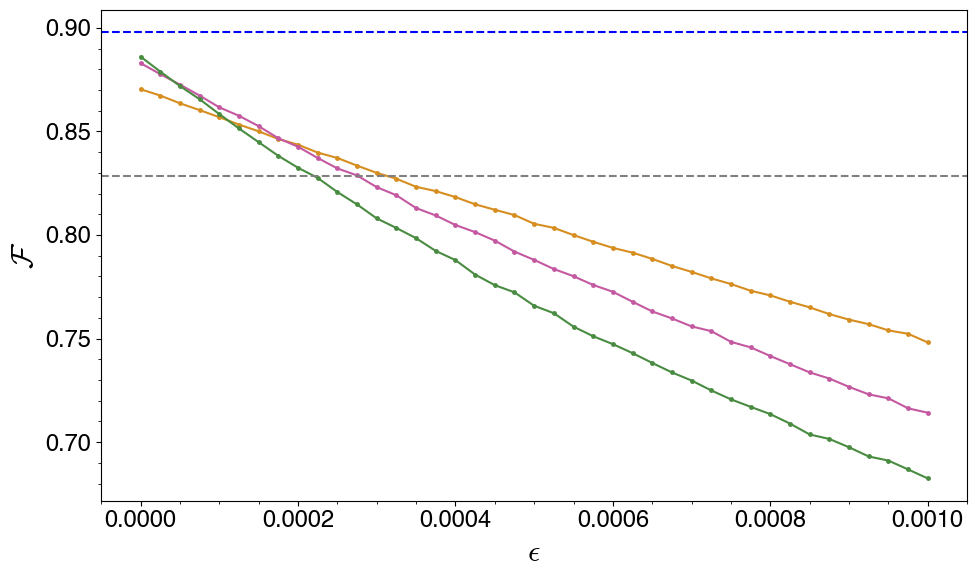

Plot saved to: aer_ryd_estimation/plotting_results/fidelity_125_k4_nshots102400_eps0.0-0.001_s41.pdf


In [118]:
import os
import csv
import glob
import re
from collections import defaultdict

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# === GLOBAL MPL FORMATTING ================================================
mpl.rcParams['font.family'] = 'Helvetica'     # Main text font
mpl.rcParams['mathtext.fontset'] = 'cm'       # Computer Modern for math
mpl.rcParams['font.size'] = 14                # Base font size
mpl.rcParams['axes.labelsize'] = 22           # Axis-label font
mpl.rcParams['legend.fontsize'] = 18          # Legend font
mpl.rcParams['xtick.labelsize'] = 17          # Tick labels
mpl.rcParams['ytick.labelsize'] = 17
# ==========================================================================

# === CONFIGURATION ========================================================
nshots      = 102400
k           = 4
eps_steps   = 41
eps_min     = 0.0
eps_max     = 0.001
eigenstates = 5

base_folder = (
    f"aer_ryd_estimation/simulation_outputs/"
    f"ryd_estimation_{eigenstates**3}_eigenstates_k{k}_shots{nshots}"
    f"_eps{eps_min}-{eps_max}_s{eps_steps}"
)
outfile_pdf = (
    f"aer_ryd_estimation/plotting_results/"
    f"fidelity_{eigenstates**3}_k{k}_nshots{nshots}_eps{eps_min}-{eps_max}_s{eps_steps}.pdf"
)

datafile           = "aer_ryd_estimation/all_states_5_eigenstates.npz"
exact_state_file   = "aer_ryd_estimation/exact_state.npz"
# ==========================================================================

# === LOAD PROBABILITIES AND STATES =======================================
data         = np.load(datafile, allow_pickle=True)
probs        = data["probs"]
input_states = data["states"]

exact_state  = np.load(exact_state_file, allow_pickle=True)["state"]
# ==========================================================================

# === COMPUTE BASE FIDELITY ===============================================
avg_base_fidelity = 0.0
for prob, state_tuple in zip(probs, input_states):
    q3_input_state = state_tuple[1]                       # third register state
    fid            = abs(np.vdot(q3_input_state, exact_state))**2
    avg_base_fidelity += prob * fid
print("Average base fidelity:", avg_base_fidelity)
print(avg_base_fidelity)
# ==========================================================================

# === LOAD QPA RESULTS, WEIGHT BY PROBS ====================================
fidelity_qpa = defaultdict(list)

for idx, prob in enumerate(probs):
    input_path = os.path.join(base_folder, f"index{idx}")
    if not os.path.exists(input_path):
        print("Missing:", input_path)
        continue

    for folder in os.listdir(input_path):
        if not folder.startswith("nqpa"):
            continue
        nqpa_val  = int(folder.replace("nqpa", ""))
        csv_path  = os.path.join(input_path, folder, "merged_results.csv")
        if not os.path.exists(csv_path):
            print("Missing CSV:", csv_path)
            continue

        with open(csv_path, newline="") as f:
            reader = csv.reader(f)
            header = next(reader)               # "epsilon, fidelity"
            for eps_str, fid_str in reader:
                eps = float(eps_str)
                fid = float(fid_str)
                fidelity_qpa[nqpa_val].append((eps, fid * prob))
# ==========================================================================

# === GROUP & AGGREGATE ====================================================
final_qpa = {}
for nqpa, entries in fidelity_qpa.items():
    buckets = defaultdict(list)
    for eps, w_fid in entries:
        buckets[eps].append(w_fid)
    final_qpa[nqpa] = {eps: sum(vals) for eps, vals in buckets.items()}
# ==========================================================================

# === PLOTTING =============================================================
plt.figure(figsize=(10, 6))

for idx, nqpa in enumerate(sorted(final_qpa.keys())):
    color = custom_colors[idx % len(custom_colors) + 1]
    eps_list     = sorted(final_qpa[nqpa].keys())
    fidelities   = [final_qpa[nqpa][eps] for eps in eps_list]
    label_prefix = "Unamplified" if nqpa == 0 else f"Amplified $N_{{\\mathrm{{trials}}}}={nqpa}$"
    plt.plot(eps_list, fidelities,  marker='.', markersize=5, color=color, label=label_prefix)

plt.axhline(y=0.8284986603752338, linestyle="--", color="gray", label="Base")
plt.axhline(y=0.897822559792652, linestyle="--", color="blue", label="Optimal")

# Fine-tune axes
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.tick_params(which="both", direction="out")

plt.xlabel(r"$\epsilon$")
plt.ylabel(r"$\mathcal{F}$")
# plt.legend(frameon=True, edgecolor="black")
plt.tight_layout()

plt.savefig(outfile_pdf)
plt.show()

print("Plot saved to:", outfile_pdf)


Loaded base fidelity for nqpa=0


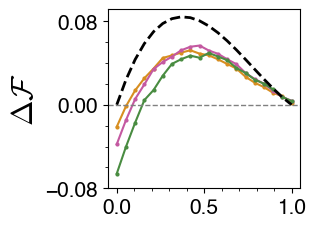

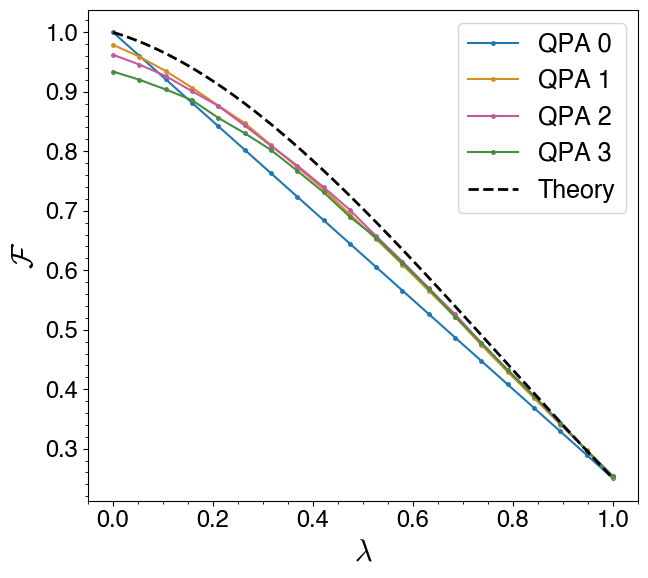

In [22]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- Configuration ---
k = 2
shots = 10000
lambda_min = 0.0
lambda_max = 1.0
lambda_steps = 20
nrandom = 5000
gatenoise = 0.0
aer = 'false'
fake = 'true'

custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']


mpl.rcParams['xtick.labelsize'] = 15          # Tick labels
mpl.rcParams['ytick.labelsize'] = 15

# Folder structure
task_type = 'three_circuits_ibm_global_sampler'
simulation_subfolder = 'simulation_outputs'
plotting_subfolder = 'plotting_results'

filesuffix = f'k{k}_shots{shots}_lambda{lambda_min}-{lambda_max}_s{lambda_steps}_r{nrandom}_g{gatenoise}_aer{aer}_fake{fake}'
plotting_folder = f'{task_type}/{plotting_subfolder}'
simulation_folder = f'{task_type}/{simulation_subfolder}'
results_folder = f'{simulation_folder}/{task_type}_{filesuffix}'

# Create directories if not exist
os.makedirs(plotting_folder, exist_ok=True)
os.makedirs(simulation_folder, exist_ok=True)

# --- Load and Plot: Δ Fidelity ---
nqpa_dirs = sorted([d for d in os.listdir(results_folder) if os.path.isdir(os.path.join(results_folder, d))])

plt.figure(figsize=(3.35,2.5))
base_fidelity = None
lambda_base = None

for i, nqpa_dir in enumerate(nqpa_dirs):
    color = custom_colors[i % len(custom_colors)]
    nqpa = nqpa_dir[4]  # Assumes folder name like "nqpaX"
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambda.csv")

    if not os.path.exists(combined_csv):
        print(f"Warning: No combined CSV found in {nqpa_dir}")
        continue

    df = pd.read_csv(combined_csv).sort_values("lambda")
    lambda_values = df['lambda'].values
    fidelities = df[f'QPA_{nqpa}'].values
    if nqpa == '0':
        base_fidelity = fidelities
        lambda_base = lambda_values
        print(f"Loaded base fidelity for nqpa=0")
        continue

    if base_fidelity is None:
        print("Error: Base fidelity (nqpa0) must be loaded first.")
        continue

    fidelity_diff = fidelities - base_fidelity
    plt.plot(lambda_values, fidelity_diff, marker='.', markersize=4, color=color, label=f'Δ Fidelity {nqpa}')

if base_fidelity is not None:
    lambda_theory = lambda_base
    theory_curve = (1 / 8) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory)
    delta_theory = theory_curve - base_fidelity
    plt.plot(lambda_theory, delta_theory, 'k--', linewidth=2, label='Theory − QPA₀')

# Format Δ plot
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.yticks([-0.08, 0, 0.08])
# plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\Delta\mathcal{F}$")
# plt.legend()
plt.tight_layout()


# Save Δ plot
delta_plot_path = f'{plotting_folder}/{task_type}_{filesuffix}_delta_fidelity.pdf'
plt.savefig(delta_plot_path)
plt.show()

mpl.rcParams['xtick.labelsize'] = 17          # Tick labels
mpl.rcParams['ytick.labelsize'] = 17

# --- Load and Plot: Absolute Fidelity ---
plt.figure(figsize=(6.7, 6))

for i, nqpa_dir in enumerate(nqpa_dirs):
    color = custom_colors[i % len(custom_colors)]
    nqpa = nqpa_dir[4]
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambda.csv")

    if not os.path.exists(combined_csv):
        continue

    df = pd.read_csv(combined_csv).sort_values("lambda")
    lambda_values = df['lambda'].values
    fidelities = df[f'QPA_{nqpa}'].values
    plt.plot(lambda_values, fidelities, marker='.', markersize=5, color=color, label=f'QPA {nqpa}')


lambda_theory = np.linspace(lambda_min, lambda_max, 300)
theory_curve = (1 / 8) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory)
plt.plot(lambda_theory, theory_curve, 'k--', linewidth=2, label='Theory')

# Format absolute plot
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\mathcal{F}$")
plt.legend()
plt.tight_layout()

# Save absolute plot
abs_plot_path = f'{plotting_folder}/{task_type}_{filesuffix}_absolute_fidelity.pdf'
plt.savefig(abs_plot_path)
plt.show()

Loaded base fidelity for nqpa=0


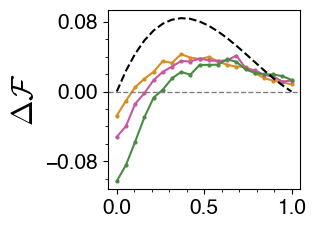

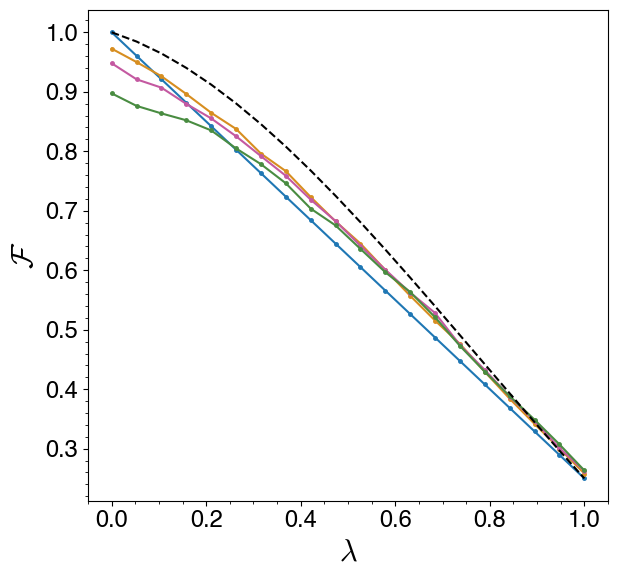

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Parameters
k = 2
shots = 1000
lambda_min = 0.0
lambda_max = 1.0
lambda_steps = 20
nrandom = 500
gatenoise = 0.0
aer = 'false'
fake = 'false'

custom_colors = ['#1f77b4', '#d78e20', '#c459a1', '#498c41']

mpl.rcParams['xtick.labelsize'] = 15          # Tick labels
mpl.rcParams['ytick.labelsize'] = 15

# Folder structure
task_type = 'three_circuits_ibm_global_sampler'
simulation_subfolder = 'simulation_outputs'
plotting_subfolder = 'plotting_results'

filesuffix = f'k{k}_shots{shots}_lambda{lambda_min}-{lambda_max}_s{lambda_steps}_r{nrandom}_g{gatenoise}_aer{aer}_fake{fake}'
plotting_folder = f'{task_type}/{plotting_subfolder}'
simulation_folder = f'{task_type}/{simulation_subfolder}'
results_folder = f'{simulation_folder}/{task_type}_{filesuffix}'

# Create directories if not exist
os.makedirs(plotting_folder, exist_ok=True)
os.makedirs(simulation_folder, exist_ok=True)

# --- Load and Plot ---
nqpa_dirs = sorted([d for d in os.listdir(results_folder) if os.path.isdir(os.path.join(results_folder, d))])

# --- Δ Fidelity Plot ---
plt.figure(figsize=(3.35,2.5))

base_fidelity = None
lambda_base = None

for i, nqpa_dir in enumerate(nqpa_dirs):
    color = custom_colors[i % len(custom_colors)]
    nqpa = nqpa_dir[4]  # Assumes folder name like "nqpaX"
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambda.csv")

    if not os.path.exists(combined_csv):
        print(f"Warning: No combined CSV found in {nqpa_dir}")
        continue

    df = pd.read_csv(combined_csv).sort_values("lambda")
    lambda_values = df['lambda'].values
    fidelities = df[f'QPA_{nqpa}'].values
    if nqpa == '0':
        base_fidelity = fidelities
        lambda_base = lambda_values
        print(f"Loaded base fidelity for nqpa=0")
        continue

    if base_fidelity is None:
        print("Error: Base fidelity (nqpa0) must be loaded first.")
        continue

    fidelity_diff = fidelities - base_fidelity
    plt.plot(lambda_values, fidelity_diff, marker='.', markersize=4, color=color, label=f'Δ Fidelity {nqpa}')

# Theory curve
if base_fidelity is not None:
    lambda_theory = lambda_base
    theory_curve = (1 / 8) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory)
    plt.plot(lambda_theory, theory_curve - base_fidelity, '--', color='black', label='Theory − QPA₀')

# Format plot
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.yticks([-0.08, 0, 0.08])
# plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\Delta\mathcal{F}$")
# plt.legend()
plt.tight_layout()

# Save and display
delta_plot_path = f'{plotting_folder}/{task_type}_{filesuffix}_delta_fidelity.pdf'
plt.savefig(delta_plot_path)
plt.show()

mpl.rcParams['xtick.labelsize'] = 17          # Tick labels
mpl.rcParams['ytick.labelsize'] = 17

# --- Absolute Fidelity Plot ---
plt.figure(figsize=(6.4, 6))

for i, nqpa_dir in enumerate(nqpa_dirs):
    color = custom_colors[i % len(custom_colors)]
    nqpa = nqpa_dir[4]
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambda.csv")

    if not os.path.exists(combined_csv):
        continue

    df = pd.read_csv(combined_csv).sort_values("lambda")
    lambda_values = df['lambda'].values
    fidelities = df[f'QPA_{nqpa}'].values
    plt.plot(lambda_values, fidelities, marker='.', markersize=5, color=color, label=f'QPA {nqpa}')

# Theory curve on absolute plot
lambda_theory = np.linspace(lambda_min, lambda_max, lambda_steps)
theory_curve = (1 / 8) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory) 
plt.plot(lambda_theory, theory_curve, '--', color='black', label='Theory')

# Format plot
ax = plt.gca()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\mathcal{F}$")
# plt.legend()
plt.tight_layout()

# Save and display
abs_plot_path = f'{plotting_folder}/{task_type}_{filesuffix}_absolute_fidelity.pdf'
plt.savefig(abs_plot_path)
plt.show()


Loaded base fidelity for nqpa=0


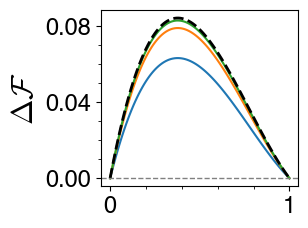

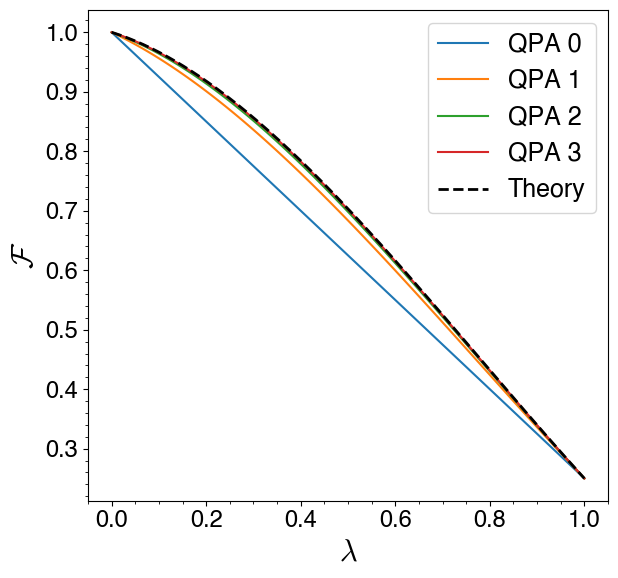

In [24]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# --- Configuration ---
k = 2
shots = 45000
lambda_min = 0
lambda_max = 1
lambda_steps = 20
nrandom = 15000
gatenoise = 0.0
aer = 'true'
fake = 'false'

# Folder structure
task_type = 'unitary_evolved_full_dm'
simulation_subfolder = 'simulation_outputs'
plotting_subfolder = 'plotting_results'

filesuffix = f'k{k}_lambda_{lambda_min}_{lambda_max}_100'
plotting_folder = f'{task_type}/{plotting_subfolder}'
simulation_folder = f'{task_type}/{simulation_subfolder}'
results_folder = f'{simulation_folder}/{task_type}_{filesuffix}'

# Create directories if not exist
os.makedirs(plotting_folder, exist_ok=True)
os.makedirs(simulation_folder, exist_ok=True)

# --- Load and Plot ---
nqpa_dirs = sorted([d for d in os.listdir(results_folder) if os.path.isdir(os.path.join(results_folder, d))])

# === Δ Fidelity Plot ===
plt.figure(figsize=(3.35,2.5))
ax = plt.gca()

base_fidelity = None
lambda_base = None

for nqpa_dir in nqpa_dirs:
    nqpa = nqpa_dir[4]  # Assumes folder name like "nqpaX"
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambdas.csv")

    if not os.path.exists(combined_csv):
        print(f"Warning: No combined CSV found in {nqpa_dir}")
        continue

    df = pd.read_csv(combined_csv).sort_values("lambda")
    lambda_values = df['lambda'].values
    fidelities = df[f'QPA_{nqpa}'].values

    if nqpa == '0':
        base_fidelity = fidelities
        lambda_base = lambda_values
        print(f"Loaded base fidelity for nqpa=0")
        continue

    if base_fidelity is None:
        print("Error: Base fidelity (nqpa0) must be loaded first.")
        continue

    fidelity_diff = fidelities - base_fidelity
    plt.plot(lambda_values, fidelity_diff, label=f'Δ Fidelity {nqpa}')

# --- Add theory curve to Δ plot ---
if base_fidelity is not None:
    lambda_theory = lambda_base
    theory_curve = (1/8) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory) 
    plt.plot(lambda_theory, theory_curve - base_fidelity, 'k--', linewidth=2, label='Theory − QPA₀')
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Format Δ plot
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
# plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\Delta\mathcal{F}$")
# plt.legend()
plt.yticks([0.0, 0.04, 0.08])
plt.tight_layout()


# Save Δ plot
delta_plot_path = f'{plotting_folder}/{task_type}_{filesuffix}_delta_fidelity.pdf'
plt.savefig(delta_plot_path)
plt.show()

# === Absolute Fidelity Plot ===
plt.figure(figsize=(6.4, 6))
ax = plt.gca()

for nqpa_dir in nqpa_dirs:
    nqpa = nqpa_dir[4]
    combined_csv = os.path.join(results_folder, nqpa_dir, "combined_lambdas.csv")

    if not os.path.exists(combined_csv):
        continue

    df = pd.read_csv(combined_csv).sort_values("lambda")
    lambda_values = df['lambda'].values
    fidelities = df[f'QPA_{nqpa}'].values
    plt.plot(lambda_values, fidelities, label=f'QPA {nqpa}')

# --- Add theory curve to absolute plot ---
lambda_theory = np.linspace(lambda_min, lambda_max, 300)
theory_curve = (1/8) * (-2 + lambda_theory) * (1 + lambda_theory) * (-4 + 3 * lambda_theory) 
plt.plot(lambda_theory, theory_curve, 'k--', linewidth=2,  label='Theory')

# Format absolute plot
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())
plt.xlabel(r"$\lambda$")
plt.ylabel(r"$\mathcal{F}$")
plt.legend()
plt.tight_layout()

# Save absolute plot
abs_plot_path = f'{plotting_folder}/{task_type}_{filesuffix}_absolute_fidelity.pdf'
plt.savefig(abs_plot_path)
plt.show()
